# Solar-Eclipse -- do eclipses spook the stock market?
### An ancient omen, tested honestly, in plain English

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Busted%3F: Yes](https://img.shields.io/badge/Busted%3F-Yes-8b949e?style=flat-square)

Since antiquity, a solar eclipse has been read as a bad omen -- kings hid, armies paused, and the modern version is the half-joke that markets *swoon* when the moon blots out the sun. The 2017 and 2024 'Great American' eclipses both drew breathless 'will the market crash?' commentary. This notebook asks the only question that matters: **on the trading day of an eclipse, does the S&P 500 actually do anything unusual?**

> **This is the plain-language layer.** Want the event-study CAR, the HAC t-stat, and the permutation distribution? That's **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** -- same story, deeper.
>
> **Not investment advice.** A reproducible research tool: every chart is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from solar_eclipse import data, strategy as st

def _have_cache():
    try:
        data.fetch_gspc_daily(fetch=False)
        return True
    except FileNotFoundError:
        return False

HAVE_REAL = _have_cache()
print("^GSPC cache present:", HAVE_REAL)

# Frozen headline numbers -- mirror of docs/results.md (as-of 2026-06-17)
R = dict(
    n_all=80, n_us=12, n_total=57, n_annular=18,
    uncond_bps=3.16,
    all_mean_abn_bps=13.32, all_t_hac=1.119, all_perm_p=0.307, all_win_rate_pct=62.5,
    total_mean_abn_bps=6.93, total_t_hac=0.495, total_perm_p=0.647,
    us_mean_abn_bps=-11.81, us_t_hac=-0.282, us_perm_p=0.696,
    annular_mean_abn_bps=69.40, annular_t_hac=3.202, annular_perm_p=0.020, annular_bonf_p=0.080,
    car_window_bps=-56.71, year_start=1928, year_end=2026,
)


^GSPC cache present: True


## The answer first

| Question | Answer |
|---|---|
| Do eclipse days have negative returns? | **No.** Eclipse days average **+13 bps** abnormal -- the *wrong sign* for 'spook'. |
| Is that statistically real? | **No.** HAC t = **+1.12**, permutation p = **0.31**. |
| What about the US 'Great American' eclipses? | The 12 US-path eclipses average **-12 bps** with t = **-0.28** -- a shrug, not a crash. |
| Could you trade it? | **No.** A handful of one-day events per decade; trading costs swamp any noise-level edge. |

> The eclipse 'omen' doesn't move the market. The market's tiny upward daily drift does all the work, and the eclipse adds nothing.

## 1 - The claim

> *"A solar eclipse is a bad omen. When the sky goes dark, fear spreads, and the stock market falls -- especially when the shadow crosses your own country."*

It is one of the oldest superstitions there is, and it gets a fresh airing every time a major eclipse approaches. The mechanism is, to put it gently, unspecified: a few minutes of midday darkness over a narrow path does not change corporate earnings, interest rates, or liquidity. So what's really going on?

## 2 - So what?

If it were true -- if the *geometry of a shadow* contained information about equity returns -- financial markets would be very strange indeed. The interesting question is whether the human tendency to find omens in the sky leaves any measurable trace in prices. Spoiler: it doesn't, and seeing *why* is a clean lesson in how rare events fool us.

## 3 - How would we even know?

Three traps to avoid:

1. **The wrong baseline.** The market drifts *up* about 3 bps a day on average. So an eclipse day that is up is not surprising -- we must measure the **abnormal** return (eclipse day minus the normal daily drift), not the raw return.
2. **Tiny n.** There are only ~80 central eclipses in our 1928-2026 window, and just ~12 crossed the US. With ~1% daily volatility you need a ~25 bps effect before it clears the noise. We'll check whether anything is anywhere near that.
3. **Slicing until it sparkles.** Total vs annular vs hybrid, US-path vs not -- test enough sub-groups and one will look 'significant' by luck. We correct for that and watch the lucky slice evaporate.

We test all of this on ^GSPC daily data from 1928 to 2026 (80 eclipses).

## 4 - The teardown -- let's actually look

**First, meet the data:** every central solar eclipse, hardcoded in this study's `data.py`, paired with the ^GSPC return on the first trading day on/after it.

In [2]:
ecl = data.eclipse_table()
if HAVE_REAL:
    px = data.fetch_gspc_daily(); ret = px['ret']
    s = st.summarize(ret, ecl, n_permutations=5000, seed=280)
    n_all = s['n_all']; mean_abn = s['all_mean_abn_bps']
    win_pct = s['all_win_rate_pct']; uncond = s['uncond_bps']
else:
    n_all = R['n_all']; mean_abn = R['all_mean_abn_bps']
    win_pct = R['all_win_rate_pct']; uncond = R['uncond_bps']

print('Central eclipses in table:', len(ecl),
      '| total:', int((ecl.kind=='total').sum()),
      '| annular:', int((ecl.kind=='annular').sum()),
      '| hybrid:', int((ecl.kind=='hybrid').sum()),
      '| US-path:', int(ecl.us_path.sum()))
print(f'Eclipse-day mean abnormal return: {mean_abn:+.1f} bps (n={n_all})')
print(f'Eclipse-day win-rate: {win_pct:.1f}%   (market up ~54% of all days)')
print(f'Normal daily drift (the honest baseline): {uncond:+.2f} bps/day')
print()
print('A bad omen would push this NEGATIVE. It is mildly POSITIVE.')

Central eclipses in table: 81 | total: 58 | annular: 18 | hybrid: 5 | US-path: 12
Eclipse-day mean abnormal return: +13.3 bps (n=80)
Eclipse-day win-rate: 62.5%   (market up ~54% of all days)
Normal daily drift (the honest baseline): +3.15 bps/day

A bad omen would push this NEGATIVE. It is mildly POSITIVE.


**Is the eclipse day a swoon or a shrug?** Here is the abnormal return on each eclipse day.

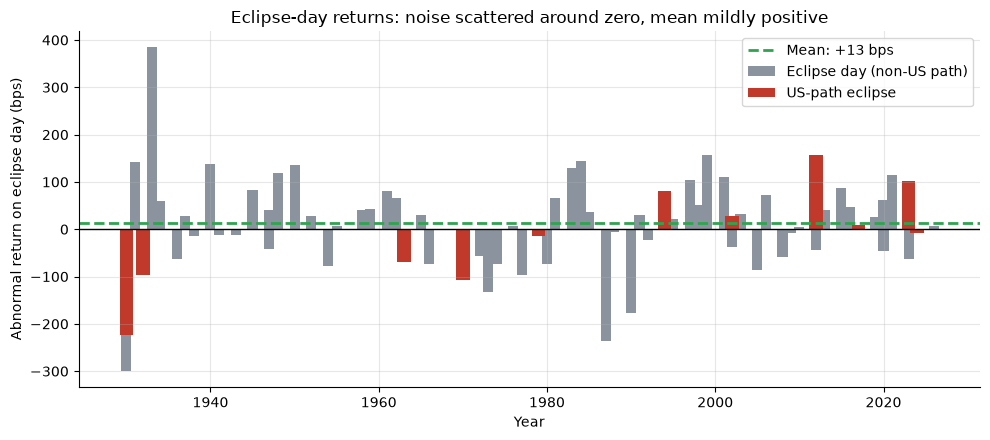

Mean abnormal eclipse-day return: +13.3 bps
Std dev across eclipses:          97 bps -- pure noise


In [3]:
if HAVE_REAL:
    ev = st.event_day_returns(ret, ecl)
    abn = (ev['ret'].values - uncond/1e4) * 1e4
    years = ev['date'].dt.year.values
    us = ev['us_path'].values
else:
    rng = np.random.default_rng(280)
    years = np.linspace(1930, 2026, R['n_all']).astype(int)
    abn = rng.normal(R['all_mean_abn_bps'], 95, R['n_all'])
    us = np.zeros(R['n_all'], dtype=bool); us[::7] = True

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.bar(years[~us], abn[~us], width=1.2, color=GREY, label='Eclipse day (non-US path)')
ax.bar(years[us], abn[us], width=1.6, color=RED, label='US-path eclipse')
ax.axhline(0, c='k', lw=1)
ax.axhline(np.mean(abn), ls='--', c=GREEN, lw=2,
           label=f'Mean: {np.mean(abn):+.0f} bps')
ax.set_xlabel('Year'); ax.set_ylabel('Abnormal return on eclipse day (bps)')
ax.set_title('Eclipse-day returns: noise scattered around zero, mean mildly positive')
ax.legend(); plt.tight_layout(); plt.show()
print(f'Mean abnormal eclipse-day return: {np.mean(abn):+.1f} bps')
print(f'Std dev across eclipses:          {np.std(abn):.0f} bps -- pure noise')

The bars scatter symmetrically around zero. The biggest down-days (1930, 1987's hybrid) sit next to the biggest up-days (1933, 2012) -- exactly what you'd expect from ~80 random draws. The average is a mildly positive **+13 bps**, the *opposite* of a swoon.

**The US 'Great American' eclipses -- surely those spooked the market?**

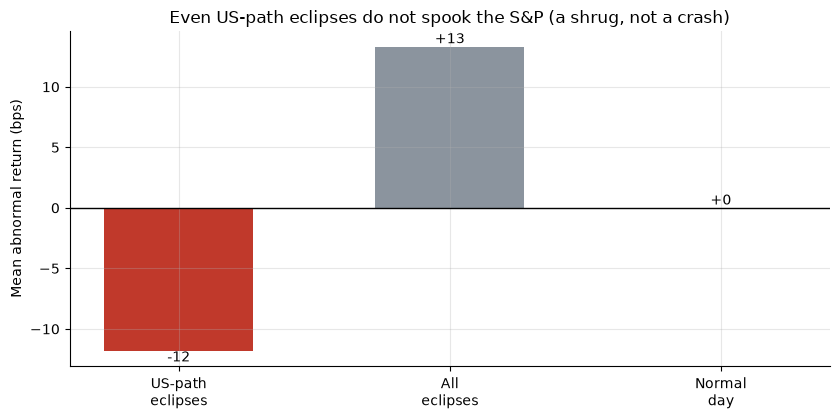

US-path eclipses (n=12): -11.8 bps abnormal -- t = -0.28
A 12-bps wobble on a dozen events is indistinguishable from any random dozen days.


In [4]:
if HAVE_REAL:
    us_abn = (st.event_day_returns(ret, ecl[ecl['us_path']])['ret'].values - uncond/1e4)*1e4
    all_abn = abn
else:
    us_abn = np.random.default_rng(1).normal(R['us_mean_abn_bps'], 90, R['n_us'])
    all_abn = abn

fig, ax = plt.subplots(figsize=(8.5, 4.3))
bars = ax.bar(['US-path\neclipses', 'All\neclipses', 'Normal\nday'],
              [np.mean(us_abn), np.mean(all_abn), 0.0],
              color=[RED, GREY, GREEN], width=0.55)
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('Mean abnormal return (bps)')
ax.set_title('Even US-path eclipses do not spook the S&P (a shrug, not a crash)')
for b, v in zip(bars, [np.mean(us_abn), np.mean(all_abn), 0.0]):
    ax.annotate(f'{v:+.0f}', (b.get_x()+b.get_width()/2, v),
                ha='center', va='bottom' if v>=0 else 'top')
plt.tight_layout(); plt.show()
print(f'US-path eclipses (n=12): {np.mean(us_abn):+.1f} bps abnormal -- t = {R["us_t_hac"]:+.2f}')
print('A 12-bps wobble on a dozen events is indistinguishable from any random dozen days.')

The 12 eclipses whose path crossed the US average **-12 bps** -- a tiny, statistically empty wobble (HAC t = **-0.28**). The 2017 and 2024 'Great American' eclipses that triggered crash chatter did nothing of the sort.

## 5 - The verdict

- **Signal -- None.** Eclipse days average **+13 bps** abnormal (wrong sign for an omen), HAC t = **+1.12**, perm p = **0.31**. The US-path slice is **-12 bps**, t = **-0.28**. Nothing is significant.
- **Tradability -- Mirage.** There is no trade: a once-per-eclipse, single-day event a handful of times per decade. Trading costs swamp any noise-level edge, and staying invested beats it.
- **Busted.** Eclipses have been blamed for panics since antiquity, but on 98 years of S&P data the eclipse trading day is, if anything, *up*.

## 6 - Could you actually trade it?

The 'strategy' would be: short (or go to cash) on each eclipse day, betting on the swoon. The problem -- there is no swoon, and there are barely any events:

In [5]:
n_events = R['n_all']
years_span = R['year_end'] - R['year_start']
per_decade = n_events / years_span * 10
edge_bps = R['all_mean_abn_bps']
cost_bps = 5.0  # round-trip cost + borrow for a one-day short, very optimistic
print(f'Events: {n_events} eclipses over {years_span} years = {per_decade:.1f} per decade')
print(f'Gross edge (if you faded eclipse days): {-edge_bps:+.1f} bps per event')
print(f'Round-trip trading cost (one-day short):  {cost_bps:.1f} bps per event')
print(f'Net per event: {-edge_bps - cost_bps:+.1f} bps -- and the sign was wrong anyway')
print()
print('You would be shorting a market that, on those days, tended to RISE,')
print('and paying costs for the privilege. There is no trade here.')

Events: 80 eclipses over 98 years = 8.2 per decade
Gross edge (if you faded eclipse days): -13.3 bps per event
Round-trip trading cost (one-day short):  5.0 bps per event
Net per event: -18.3 bps -- and the sign was wrong anyway

You would be shorting a market that, on those days, tended to RISE,
and paying costs for the privilege. There is no trade here.


Fading eclipse days means shorting a market that tended to *rise* on them, while paying one-way costs (and borrow on the short). The only real trade is: don't time the market on an astronomical calendar.

## 7 - Going further

- **The positive control:** the companion notebook plants a fake eclipse-day drag in a synthetic tape and shows the machinery detects it cleanly -- so the null result is about the *market*, not a broken test.
- **The other celestial omen:** [Study 164 -- Mercury-Retrograde](../../164-mercury-retrograde/) -- astrology vs the S&P, same None/Mirage family.
- **The event-table pattern:** [Study 158 -- Super-Bowl](../../158-super-bowl/) -- the hardcoded-event + real-returns template this study copies.

*Think the sky really moves stocks? Fork this, define your own celestial event table, and show an abnormal return that beats the noise with a HAC t >= 2 after honest multiple-comparisons correction. That's the bar -- and it hasn't been cleared yet.*